## Question 1: Piecewise Linear Intensity Transformation

### Methodology
In this task, a piecewise linear intensity transformation is implemented to alter the brightness and contrast of an image based on predefined breakpoints. The transformation function maps input pixel intensities to new output intensities using linear interpolation between the specified coordinate pairs $(x_i, y_i)$. 

To achieve this efficiently in Python using OpenCV, we compute a **Look-Up Table (LUT)** of size 256 (for 8-bit grayscale images). For every possible input pixel intensity $x \in [0, 255]$, we determine which segment $[x_i, x_{i+1}]$ it falls into and calculate the corresponding output $y$ using the linear equation:

$$y = m \cdot x + c$$

where the slope $m = \frac{y_{i+1} - y_i}{x_{i+1} - x_i}$ and the intercept $c = y_i - m \cdot x_i$. The calculated values are clipped to the $[0, 255]$ range and stored in the LUT. Finally, `cv2.LUT()` is used to quickly map all pixels in the input image to their new values.

### Implementation and Experiments
1. **Given Breakpoints:** The initial breakpoints `[[0, 0], [50, 50], [100, 150], [150, 255], [255, 255]]` apply a transformation that leaves the darkest shadows ($0-50$) untouched but increases the contrast and brightness for the mid-tones and highlights, pushing the input intensity of $150$ to a maximum white of $255$. This leads to a brighter overall image.
2. **Custom Breakpoints (Visually Pleasing):** To experiment with a visually pleasing output, we can define custom breakpoints like `[[0, 0], [70, 30], [180, 220], [255, 255]]`. This specific curve forms a subtle "S-curve". It slightly compresses the shadows (making dark areas richer), steepens the slope in the mid-tones (increasing overall contrast), and compresses the highlights to prevent clipping, often resulting in a more dramatic and aesthetically pleasing portrait.


Results using the breakpoints provided in the question:


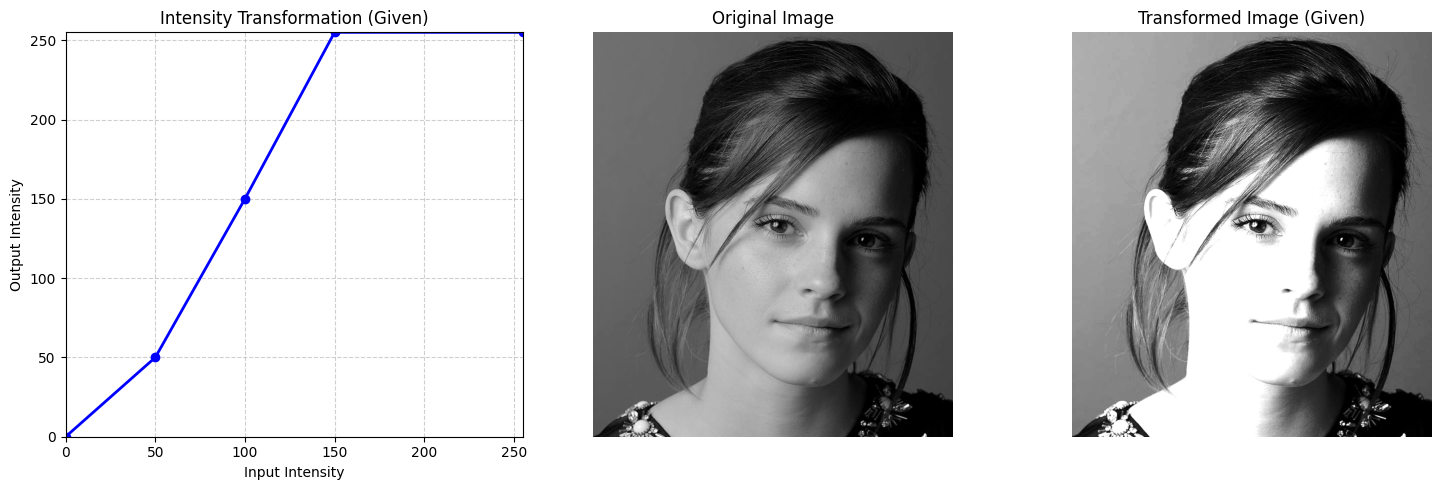

Results using custom breakpoints for a visually pleasing output:


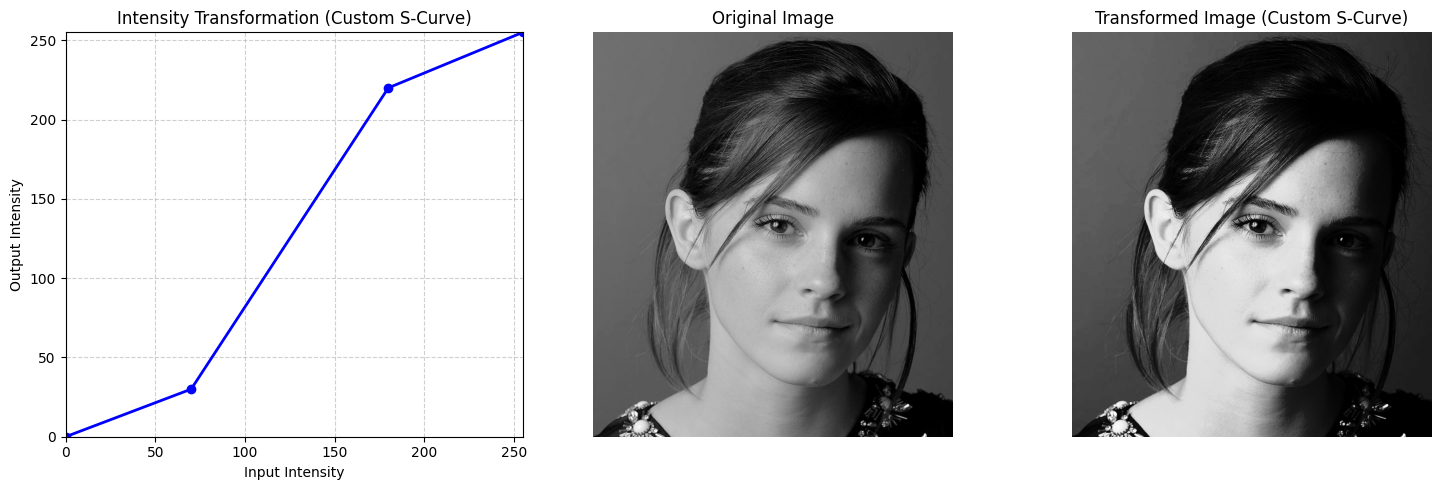

In [9]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def intensity_transform(im, breakpoints):
    
    lut = np.zeros(256, dtype=np.uint8)
    
    for i in range(len(breakpoints) - 1):
        x1, y1 = breakpoints[i]
        x2, y2 = breakpoints[i+1]
        
        if x2 - x1 != 0:
            m = (y2 - y1) / (x2 - x1)
        else:
            m = 0
            
        c = y1 - m * x1
        
        for x in range(x1, x2 + 1):
            if x < 256:
                val = m * x + c
                lut[x] = np.clip(val, 0, 255)
                
    transformed_im = cv2.LUT(im, lut)
    
    return transformed_im
img_path = r'D:\VISION\VISION-ASSIGNEMNT\images\q1.jpeg'

original_image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)


breakpoints_given = [
    [0, 0],
    [50, 50],
    [100, 150],
    [150, 255],
    [255, 255]
]

transformed_image_given = intensity_transform(original_image, breakpoints_given)

def plot_results(original, transformed, breakpoints, title_suffix=""):
    x_coords = [bp[0] for bp in breakpoints]
    y_coords = [bp[1] for bp in breakpoints]
    
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.plot(x_coords, y_coords, marker='o', color='blue', linewidth=2)
    plt.title(f'Intensity Transformation {title_suffix}')
    plt.xlabel('Input Intensity')
    plt.ylabel('Output Intensity')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xlim([0, 255])
    plt.ylim([0, 255])
    
    plt.subplot(1, 3, 2)
    plt.imshow(original, cmap='gray', vmin=0, vmax=255)
    plt.title('Original Image')
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.imshow(transformed, cmap='gray', vmin=0, vmax=255)
    plt.title(f'Transformed Image {title_suffix}')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

print("Results using the breakpoints provided in the question:")
plot_results(original_image, transformed_image_given, breakpoints_given, "(Given)")

breakpoints_custom = [
    [0, 0],
    [70, 30],   
    [180, 220],
    [255, 255]  
]

transformed_image_custom = intensity_transform(original_image, breakpoints_custom)

print("Results using custom breakpoints for a visually pleasing output:")
plot_results(original_image, transformed_image_custom, breakpoints_custom, "(Custom S-Curve)")


## Question 2: Accentuation of Specific Tissues

### Methodology
To accentuate specific regions in a medical image, such as white matter or gray matter in a brain proton density scan, we can use a piecewise linear intensity transformation called **contrast stretching** or **intensity windowing**. 

The goal is to increase the contrast for a specific, narrow range of input intensities corresponding to the tissue of interest. We achieve this by assigning a steep slope to that intensity range in our transformation curve. This maps a small range of input pixel values to a much wider range of output pixel values, making the subtle details within that tissue highly visible. Conversely, the intensity ranges corresponding to other tissues and the background are compressed using a shallow slope, pushing them towards black or white to reduce their visual distraction.

1. **(a) Accentuate White Matter:** In typical brain proton density or T1 MRI scans, white matter appears brighter than gray matter. To accentuate it, we identify the higher intensity band corresponding to white matter and create breakpoints that aggressively stretch this band (e.g., steepening the curve between input intensities of ~150 to ~220).
2. **(b) Accentuate Gray Matter:** Gray matter generally occupies the mid-tone intensity range. To accentuate it, we steepen the transformation curve in the middle of the histogram (e.g., stretching input intensities from ~80 to ~140), while flattening the curve for the darker cerebrospinal fluid (CSF) and the brighter white matter.

*Note: The exact intensity values for gray and white matter vary depending on the specific image. Looking at the image histogram helps precisely locate these intensity bands.*


Accentuation of White Matter:


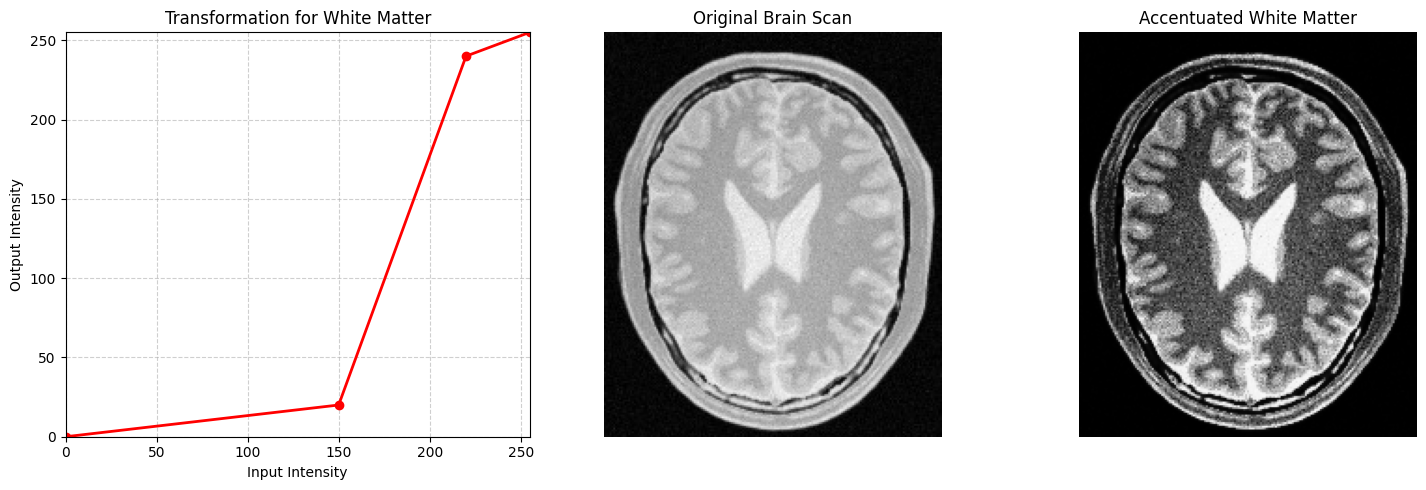

Accentuation of Gray Matter:


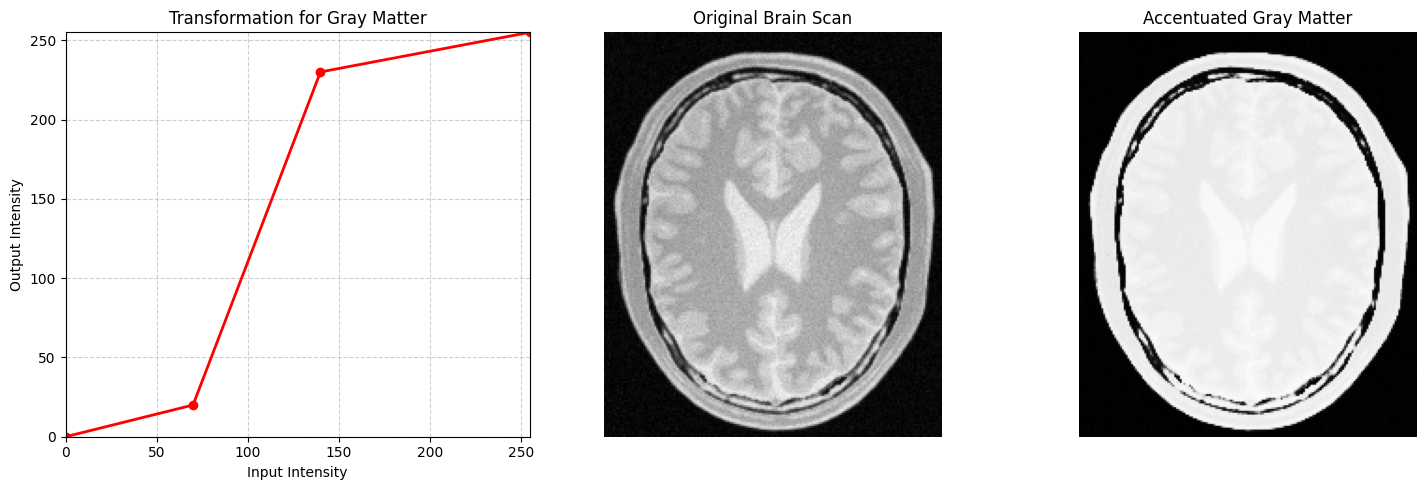

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

img_path = r'D:\VISION\VISION-ASSIGNEMNT\images\q2.jpeg' 
brain_image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    
breakpoints_wm = [
    [0, 0],
    [150, 20],   
    [220, 240],  
    [255, 255]
]

accentuated_wm = intensity_transform(brain_image, breakpoints_wm)

breakpoints_gm = [
    [0, 0],
    [70, 20],    
    [140, 230],  
    [255, 255]   
]

accentuated_gm = intensity_transform(brain_image, breakpoints_gm)

def plot_accentuation(original, transformed, breakpoints, target_name):
    x_coords = [bp[0] for bp in breakpoints]
    y_coords = [bp[1] for bp in breakpoints]
    
    plt.figure(figsize=(15, 5))
    
    # Plot 1: Intensity Transformation Curve
    plt.subplot(1, 3, 1)
    plt.plot(x_coords, y_coords, marker='o', color='red', linewidth=2)
    plt.title(f'Transformation for {target_name}')
    plt.xlabel('Input Intensity')
    plt.ylabel('Output Intensity')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xlim([0, 255])
    plt.ylim([0, 255])
    
    # Plot 2: Original Image
    plt.subplot(1, 3, 2)
    plt.imshow(original, cmap='gray', vmin=0, vmax=255)
    plt.title('Original Brain Scan')
    plt.axis('off')
    
    # Plot 3: Transformed Image
    plt.subplot(1, 3, 3)
    plt.imshow(transformed, cmap='gray', vmin=0, vmax=255)
    plt.title(f'Accentuated {target_name}')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Display results
print("Accentuation of White Matter:")
plot_accentuation(brain_image, accentuated_wm, breakpoints_wm, "White Matter")

print("Accentuation of Gray Matter:")
plot_accentuation(brain_image, accentuated_gm, breakpoints_gm, "Gray Matter")


## Question 3: Gamma Correction in L*a*b* Color Space

### Methodology
In this task, we apply gamma correction to an image to adjust its overall brightness and contrast, specifically targeting the dark regions (like the rocks in Fig 3). 

1. **Why L*a*b* Color Space?** If we apply intensity transformations directly to RGB channels, we risk altering the color balance (chromaticity) of the image, causing unnatural color shifts. By converting the image to the **CIE L*a*b*** color space, we separate the Lightness (L) from the color information (a and b channels). We can safely manipulate the L plane to change brightness without affecting the actual colors in the image.
2. **Gamma Correction:** Gamma correction is a non-linear operation described by the power-law equation: 
   $$V_{out} = c \cdot V_{in}^{\gamma}$$
   For an 8-bit image, the pixel values are normalized to $[0, 1]$, raised to the power of $\gamma$, and then scaled back to $[0, 255]$. 
   * A **$\gamma < 1$** expands the dark regions (increasing their contrast and brightness) while compressing the bright regions. This is ideal for revealing details hidden in shadows.
   * A **$\gamma > 1$** does the opposite, darkening the image.

### Results
* **Gamma Value:** I applied a gamma value of **$\gamma = 0.5$**. This value was chosen because it significantly brightens the dark, underexposed rocks in the background, revealing texture and detail, without completely washing out the bright white dress.
* **Histograms:** The histograms clearly illustrate the effect. The histogram of the original Lightness (L) plane has a heavy concentration of pixels clustered near the left side (dark values). After applying the $\gamma = 0.5$ correction, the histogram is "stretched" and shifted towards the right (mid-tones and highlights), demonstrating that the shadow regions have been successfully brightened.
